# Columnar genomeblocks: a notebook tour (prototype)

Branch `columnar-prototype` · package `genomeblocks.columnar`

**The idea in one picture.** Every table shares one `Genome`. The *row number* links the tables:

```
Genome  (chrom <-> code, shared by every table)
 ├─ Loci     chrom | start | end | strand          row i = CRE i, everywhere
 │    ├─ labels[i]    signal_cube[i]    A.vp[...][i]
 │    └─ Architecture  edges table: src | tgt | w | n | d   (src, tgt = Loci rows)
 │                     sorted:  | cis chr1 | cis chr2 | ... | trans |
 └─ Genes    genes ⇄ transcripts ⇄ exons   (linked by row numbers)
```

Data: the synthetic hg38-shaped benchmark set. It has 100k CREs, 20k genes and 52.5k loops (2.5k of them inter-chromosomal), plus 5 kb Hi-C. Make it with `benchmarks/make_data.py`.

In [1]:
import time
import warnings
from contextlib import contextmanager
warnings.filterwarnings("ignore", message=".*(cairo|draw module).*")   # graph-tool without its drawing backend

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

@contextmanager
def timer(label):
    t = time.perf_counter()
    yield
    print(f"⏱  {label}: {1000 * (time.perf_counter() - t):,.0f} ms")

with timer("import genomeblocks.columnar"):
    import genomeblocks.columnar as gbc
    from genomeblocks.locus import Locus

DATA = "../../benchmarks/data"

⏱  import genomeblocks.columnar: 2 ms


## 1 · Load CREs: a table, not a list of objects

Four numpy columns. `make` sorts rows into genome order, so each chromosome becomes one block of rows.

In [2]:
with timer("Loci.make, 100k peaks"):
    cre = gbc.Loci.make(f"{DATA}/peaks_A_100000.bed")
cre

⏱  Loci.make, 100k peaks: 75 ms


row,chrom,start,end,strand
0,chr1,"78,323","78,558",.
1,chr1,"97,098","97,696",.
2,chr1,"103,631","104,116",.
3,chr1,"145,482","145,774",.
4,chr1,"382,254","382,609",.
⋮,⋮,⋮,⋮,⋮
99997,chrX,"155,852,328","155,852,761",.
99998,chrX,"155,967,164","155,967,471",.
99999,chrX,"155,978,639","155,978,904",.


Looking at one row still gives you a normal `Locus`. It's a *view* onto the columns, so nothing is copied:

In [3]:
v = cre[0]
print(v, "| isinstance(v, Locus):", isinstance(v, Locus), "| center:", v.center)
print("lookup by uid -> row", cre[v.uid].row)

chr21 = cre.by_chrom("chr21")
print(chr21, "| shares memory with cre:", np.shares_memory(chr21.starts, cre.starts))

Locus[0](chr1:78323-78558(.)) | isinstance(v, Locus): True | center: 78440


lookup by uid -> row 0
Loci(n=1,552, chroms=1, columnar, sorted) | shares memory with cre: True


## 2 · Genes: three linked tables

In [4]:
with timer("Genes.make, GTF with 877k lines"):
    genes = gbc.Genes.make(f"{DATA}/genes.gtf")
genes

⏱  Genes.make, GTF with 877k lines: 935 ms


genes,"20,000 rows (gene_id, gene_name, gene_type)"
transcripts,"70,028 rows (transcript_id, gene → genes row)"
features,"491,201 exons · 211,471 CDS · 84,246 UTR (kind, transcript → transcripts row)"
coordinates,18.4 MB of arrays
annotation index,built on first use


In [5]:
g = genes["GENE0"]
print(g, "\nTSS:", g.tss)
g.transcripts.to_pandas()

Gene(GENE0, chr2:43,925,015-43,927,015(-), protein_coding) 
TSS: Locus(chrom='chr2', start=43927015, end=43927014, strand='.')


,chrom,start,end,strand,transcript_id,gene
0,chr2,43925015,43927015,-,ENST00000000000.1,0
1,chr2,43925608,43926397,-,ENST00000000001.1,0
2,chr2,43925198,43926848,-,ENST00000000002.1,0


## 3 · Annotate every CRE at once

The annotation index (promoters, exons, UTRs, gene bodies) is built once and cached. After that, labelling is five vectorised overlap tests.

In [6]:
from genomeblocks.columnar.genes import LABELS

with timer("annotation index (first use only)"):
    genes.annot
with timer("label 100k CREs"):
    labels = genes.labels(cre)          # one small int per CRE row
pd.Series(LABELS[labels]).value_counts().to_frame("CREs")

⏱  annotation index (first use only): 146 ms


⏱  label 100k CREs: 24 ms


,CREs
Intergenic,75177
Intronic,13060
Exonic,6189
3UTR,2152
5UTR,1740
Promoter-TSS,1682


## 4 · Architecture: one graph stored as two tables

Vertices are the CRE rows. Edges are a table of `src | tgt | w | n | d`, sorted into per-chromosome **cis blocks** followed by one **trans block**. These loops include 2.5k inter-chromosomal ones.

In [7]:
with timer("make → add_mcool → normalize → annotate → strength"):
    A = (gbc.Architecture.make(cre, f"{DATA}/loops_trans.bedpe")
           .add_mcool(f"{DATA}/hic_trans_5kb.cool")
           .normalize()
           .annotate(genes)
           .strength())
A

[INFO] 52500 loops | 52500 mapped (100.0%) | loci=74791, links=120230 (5863 trans)


[INFO] Set distributed weights for 14282/120230 edges from cooler. [w]
[INFO] Power-law fit: alpha=0.117, C=1.992e+00 on 114367 cis edges; 5863 trans edges use the mean trans weight → ep.n


[INFO] Annotated 74791 loci: 1254 promoter CREs | 3224/73537 non-promoter CREs assigned to a top-'n' promoter gene → vp.gene.
[INFO] Summed ep.n → vp.strength (node strength).
⏱  make → add_mcool → normalize → annotate → strength: 891 ms


block,edge rows,edges
chr1,"0–9,479","9,479"
chr2,"9,479–18,891","9,412"
chr3,"18,891–26,259","7,368"
chr4,"26,259–32,772","6,513"
⋮,,
chr22,"105,791–107,730","1,939"
chrX,"107,730–114,367","6,637"
trans,"114,367–120,230","5,863"


### The edge table drawn as a matrix

Rows and columns are CREs in genome order. Cis edges sit in the diagonal blocks (one block per chromosome). Trans edges are the red dots between blocks. It is one graph, and nothing was split apart.

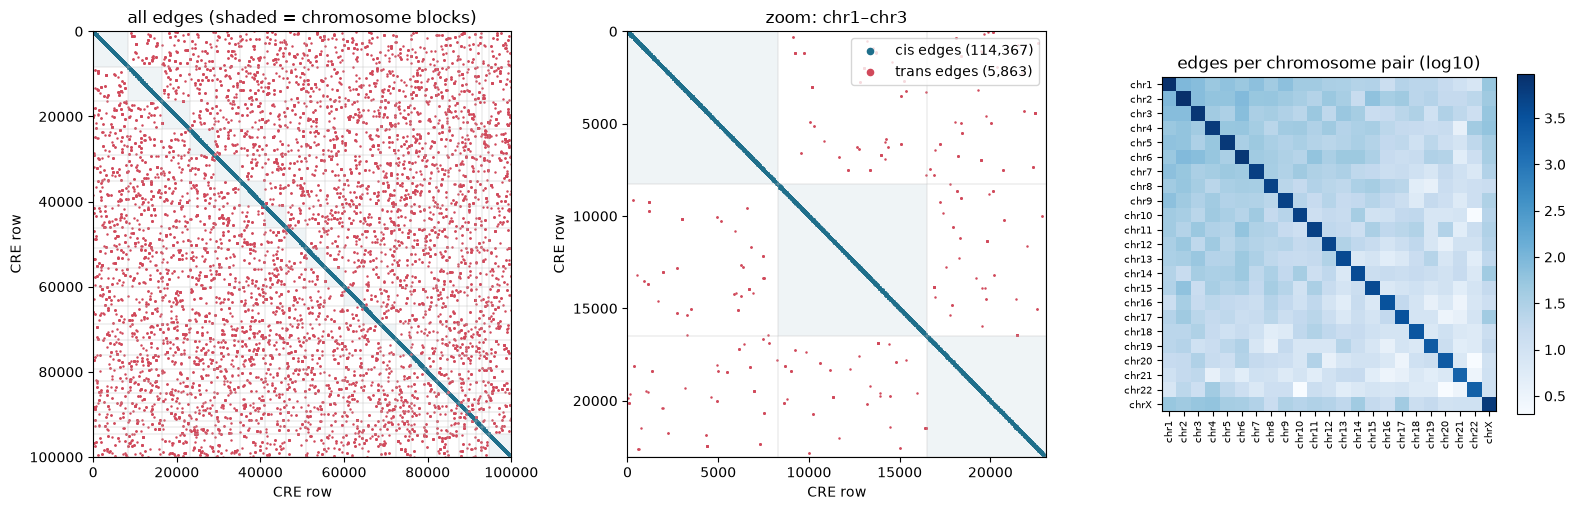

In [8]:
from matplotlib.patches import Rectangle

def draw_edges(ax, lo, hi, title):
    for c, (a, b) in cre.chrom_offsets.items():          # one shaded square per chromosome block
        if b > lo and a < hi:
            ax.add_patch(Rectangle((a, a), b - a, b - a, color="#1f6f8b", alpha=0.07, lw=0))
            ax.axvline(b, lw=0.3, c="0.75"); ax.axhline(b, lw=0.3, c="0.75")
    keep = (A.src >= lo) & (A.tgt < hi)
    cis = A.is_cis & keep
    trans = ~A.is_cis & keep
    for x, y in ((A.src, A.tgt), (A.tgt, A.src)):        # both triangles
        ax.scatter(x[cis], y[cis], s=0.6, c="#1f6f8b", rasterized=True)
        ax.scatter(x[trans], y[trans], s=0.6, c="#d1495b", rasterized=True)
    ax.set(xlim=(lo, hi), ylim=(hi, lo), xlabel="CRE row", ylabel="CRE row", title=title)

fig, ax = plt.subplots(1, 3, figsize=(16, 5.2))
draw_edges(ax[0], 0, len(cre), "all edges (shaded = chromosome blocks)")
z0, z1 = cre.chrom_offsets["chr1"][0], cre.chrom_offsets["chr3"][1]
draw_edges(ax[1], z0, z1, "zoom: chr1–chr3")
ax[1].scatter([], [], s=20, c="#1f6f8b", label=f"cis edges ({A.cis.n_links:,})")
ax[1].scatter([], [], s=20, c="#d1495b", label=f"trans edges ({A.trans.n_links:,})")
ax[1].legend(loc="upper right", frameon=True)

M = A.block_counts()
im = ax[2].imshow(np.log10(M.to_numpy() + 1), cmap="Blues")
ax[2].set_xticks(range(len(M)), M.columns, rotation=90, fontsize=7)
ax[2].set_yticks(range(len(M)), M.index, fontsize=7)
ax[2].set_title("edges per chromosome pair (log10)")
fig.colorbar(im, ax=ax[2], shrink=0.8)
plt.tight_layout()

Cis edges hug the diagonal inside their chromosome's square, because most loops are short-range. Trans edges land in the off-diagonal squares. The heatmap counts the same thing per chromosome pair.

## 5 · Views: cut the graph without copying it

In [9]:
with timer("A.chrom('chr8')"):
    a8 = A.chrom("chr8")
with timer("A.cis and A.trans"):
    cis_part, trans_part = A.cis, A.trans
print(a8)
print(trans_part)
print("zero-copy:", np.shares_memory(a8.src, A.src), np.shares_memory(trans_part.ep.n, A.ep.n))

⏱  A.chrom('chr8'): 0 ms
⏱  A.cis and A.trans: 0 ms
Architecture(name='Skeleton:chr8', loci=3,454, links=5,180 [5,180 cis · 0 trans], edge_props=[w, n, d], vertex_props=[annot, gene, strength])
Architecture(name='Skeleton:trans', loci=7,315, links=5,863 [0 cis · 5,863 trans], edge_props=[w, n, d], vertex_props=[annot, gene, strength])
zero-copy: True True


In [10]:
with timer("region chr8:20-40 Mb (first call also builds the interval index)"):
    r = A.region("chr8:20,000,000-40,000,000")
r

⏱  region chr8:20-40 Mb (first call also builds the interval index): 45 ms


block,edge rows,edges
chr8,0–714,714
trans,714–714,0


## 6 · A CRE's partners include its trans partners

In [11]:
t = A.trans
k = int(np.argmax(t.ep.w))           # the strongest trans edge
row = int(t.src[k])
A.neighbors(row)

,row,uid,chrom,cis,w,n,d
0,7953,chr1:235977473-235977860(.),chr1,True,0.0,0.00000,790028.0
1,44594,chr7:110757553-110758161(.),chr7,False,48.0,4.47778,inf
2,7887,chr1:234153954-234154363(.),chr1,True,0.0,0.00000,1033480.0
3,7888,chr1:234155286-234156372(.),chr1,True,0.0,0.00000,1031809.0


## 7 · Per-chromosome work

Each cis block is independent, so you can loop over `A.chroms()` or hand the blocks to a process pool. Trans edges are one more small block at the end.

In [12]:
with timer("per-chromosome summary"):
    per_chrom = pd.DataFrame([
        {"chrom": c, "edges": v.n_links, "loci": v.n_loci,
         "median distance (kb)": np.median(v.ep.d) / 1e3,
         "edges with Hi-C contacts": int((v.ep.w > 0).sum())}
        for c, v in A.chroms()])
per_chrom.head(8)

⏱  per-chromosome summary: 10 ms


,chrom,edges,loci,median distance (kb),edges with Hi-C contacts
0,chr1,9479,6112,151.7520,604
1,chr2,9412,5945,119.1730,744
2,chr3,7368,4767,157.0765,437
3,chr4,6513,4361,161.8260,394
4,chr5,6934,4425,126.5175,537
5,chr6,7375,4390,104.7980,727
6,chr7,5595,3803,143.6910,381
7,chr8,5180,3454,157.4705,315


## 8 · Graph algorithms see every edge, cis and trans

In [13]:
with timer("graph-tool Graph from the tables (first call also imports graph-tool)"):
    g = A.graph()
with timer("connected components"):
    comp = A.components()
comp_cis = A.cis.components(name="component_cis_only")
n_comp = lambda c: len(np.unique(c[c >= 0]))
big = lambda c: np.bincount(c[c >= 0]).max()
print(f"components   with trans: {n_comp(comp):,}   cis only: {n_comp(comp_cis):,}")
print(f"largest one  with trans: {big(comp):,} CREs   cis only: {big(comp_cis):,} CREs")

⏱  graph-tool Graph from the tables (first call also imports graph-tool): 459 ms
⏱  connected components: 14 ms
components   with trans: 5,606   cis only: 6,638
largest one  with trans: 46,434 CREs   cis only: 521 CREs


In [14]:
import graph_tool.all as gt

with timer("pagerank"):
    pr = gt.pagerank(g)
A.vp.pagerank = np.asarray(pr.a)       # vertex i = Loci row i, so it just lines up
(A.to_frame()[["uid", "annot", "gene", "strength", "component", "pagerank"]]
   .sort_values("pagerank", ascending=False).head())

⏱  pagerank: 76 ms


,uid,annot,gene,strength,component,pagerank
51026,chr12:120391877-120392528(.),Intergenic,,0.000000,21357,0.000054
33652,chr7:125449293-125449685(.),Intergenic,,0.000000,1,0.000051
38068,chr9:1387996-1388267(.),Intergenic,,0.000000,15902,0.000049
384,chr1:13815810-13816019(.),Intergenic,,0.000000,131,0.000048
43588,chr10:83159021-83159221(.),Intergenic,,2.612038,1,0.000047


## 9 · Row alignment: signal, labels and graph columns line up by position

`signal()` here is the **classic** genomeblocks function, unchanged, running on the columnar Loci. Its cube rows are CRE rows, so selecting hubs is just an index.

⏱  signal() for 28,498 CREs × 2 bigWigs: 2,323 ms
cube: (28498, 2, 60) → row j is CRE pick[j]


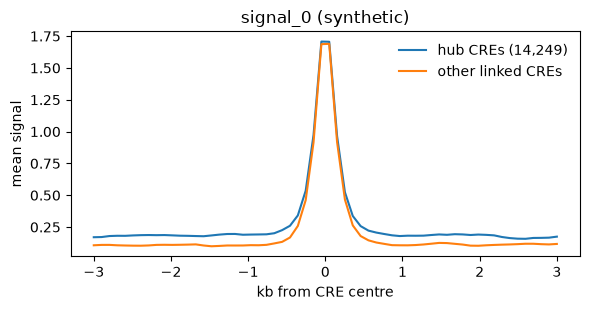

In [15]:
hubs = A.prime_hubs(verbose=False)
hub_rows = np.array([cre.row(u) for u in hubs["hub_uids"]])
rest = np.setdiff1d(np.flatnonzero(A.degree > 0), hub_rows)
pick = np.concatenate([hub_rows, np.random.default_rng(0).choice(rest, len(hub_rows), replace=False)])

with timer(f"signal() for {len(pick):,} CREs × 2 bigWigs"):
    cube = cre.take(pick).signal([f"{DATA}/signal_0.bw", f"{DATA}/signal_1.bw"],
                                 n_bins=60, progress=False, verbose=False)
print("cube:", cube.shape, "→ row j is CRE pick[j]")

x = np.linspace(-3, 3, 60)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(x, np.nanmean(cube[:len(hub_rows), 0], 0), label=f"hub CREs ({len(hub_rows):,})")
ax.plot(x, np.nanmean(cube[len(hub_rows):, 0], 0), label="other linked CREs")
ax.set(xlabel="kb from CRE centre", ylabel="mean signal", title="signal_0 (synthetic)")
ax.legend(frameon=False); plt.tight_layout()

## 10 · A genome-wide test in one cell

Do edges that touch a promoter have higher O/E than other edges? Shuffle the promoter labels across linked CREs 1,000 times. Every permutation is a few array operations over all 120k edges.

*The data is synthetic, so expect no biological effect. The point is that the test is quick to run.*

In [16]:
is_prom = A.vp.annot == "Promoter-TSS"
oe = A.ep.n
touch = is_prom[A.src] | is_prom[A.tgt]
obs = oe[touch].mean() - oe[~touch].mean()

linked = np.flatnonzero(A.degree > 0)
k = int(is_prom[linked].sum())
rng = np.random.default_rng(1)
null = np.empty(1000)
with timer("1,000 permutations over 120k edges"):
    for i in range(1000):
        lab = np.zeros(len(cre), bool)
        lab[rng.choice(linked, k, replace=False)] = True
        t = lab[A.src] | lab[A.tgt]
        null[i] = oe[t].mean() - oe[~t].mean()
p = (1 + (null >= obs).sum()) / 1001
print(f"observed Δ O/E = {obs:.3f}   permutation p = {p:.3f}")

⏱  1,000 permutations over 120k edges: 1,074 ms
observed Δ O/E = -0.009   permutation p = 0.836


## 11 · Save the session, reload in milliseconds

In [17]:
import os, tempfile
SESSION = tempfile.mkdtemp(prefix="gb_session_")
with timer("save Architecture (+ its Loci) and Genes as parquet"):
    A.save(f"{SESSION}/architecture")
    genes.save(f"{SESSION}/genes")
size = sum(os.path.getsize(os.path.join(d, f)) for d, _, fs in os.walk(SESSION) for f in fs)
print(f"on disk: {size / 1e6:.1f} MB")

with timer("load both back"):
    A2 = gbc.Architecture.load(f"{SESSION}/architecture")
    genes2 = gbc.Genes.load(f"{SESSION}/genes")
print(A2)
print("identical:", np.array_equal(A2.ep.n, A.ep.n), np.array_equal(A2.vp.gene, A.vp.gene))

⏱  save Architecture (+ its Loci) and Genes as parquet: 549 ms
on disk: 14.0 MB


⏱  load both back: 374 ms
Architecture(name='Skeleton', loci=74,791, links=120,230 [114,367 cis · 5,863 trans], edge_props=[w, n, d], vertex_props=[annot, gene, strength, component, component_cis_only, pagerank])
identical: True True


## 12 · Hand the tables to other tools

In [18]:
A.edges_frame().head()

,src,tgt,uid1,uid2,chrom1,chrom2,cis,w,n,d
0,0,7,chr1:78323-78558(.),chr1:818726-818960(.),chr1,chr1,True,0.0,0.0,740403.0
1,1,12,chr1:97098-97696(.),chr1:1059279-1059756(.),chr1,chr1,True,0.0,0.0,962120.0
2,2,10,chr1:103631-104116(.),chr1:991046-992412(.),chr1,chr1,True,0.0,0.0,887856.0
3,2,46,chr1:103631-104116(.),chr1:2805029-2805471(.),chr1,chr1,True,0.0,0.0,2701377.0
4,3,27,chr1:145482-145774(.),chr1:2066754-2067575(.),chr1,chr1,True,0.0,0.0,1921536.0


In [19]:
print(cre.to_arrow().schema)
cre.to_polars().head(3)

chrom: dictionary<values=string, indices=int32, ordered=0>
start: int64
end: int64
strand: dictionary<values=string, indices=int8, ordered=0>


chrom,start,end,strand
cat,i64,i64,cat
"""chr1""",78323,78558,"""."""
"""chr1""",97098,97696,"""."""
"""chr1""",103631,104116,"""."""


In [20]:
with timer("to_legacy(): the classic graph-tool Architecture (e.g. for its draw helpers)"):
    O = A.to_legacy()
O

⏱  to_legacy(): the classic graph-tool Architecture (e.g. for its draw helpers): 763 ms


Architecture(name='Skeleton', loci=74791, links=120230, vertex_props=[uid, annot, gene, strength, component, component_cis_only, pagerank], edge_props=[w, n, d])

## Cheat-sheet

| you want | write | cost |
|---|---|---|
| one CRE as an object | `cre[i]`, `cre["chr1:…"]` | µs |
| one chromosome of CREs | `cre.by_chrom("chr8")` | view, no copy |
| labels for all CREs | `genes.labels(cre)` | ~25 ms / 100k |
| graph for one chromosome | `A.chrom("chr8")` | view, no copy |
| cis only / trans only | `A.cis`, `A.trans` | view, no copy |
| a CRE's partners (cis + trans) | `A.neighbors(row)` | µs |
| graph algorithms | `A.graph()` → graph-tool | built once |
| per-CRE results | `A.vp[name][row]`, aligned with `cre` | — |
| save / reload | `A.save(path)` / `Architecture.load(path)` | parquet |
| classic API | `cre.signal(...)`, `A.to_legacy()` | unchanged |